# Soil raster map — Niedersachsen test area

Navigable folium/Leaflet map that pulls **raster imagery** (not point values) from every source in the table that offers rasters:

| Source | Raster mechanism | Coverage |
|---|---|---|
| ISRIC SoilGrids v2.0 | WMS tiles (`maps.isric.org/mapserv?map=/map/<prop>.map`) + raw GetMap PNG for the AOI | Global, 250 m |
| LBEG NIBIS BK50 + Bodenschätzung | WMS tiles (`nibis.lbeg.de ... ogc.ashx?PKGID=24`) | Niedersachsen, 1:50k / 1:5k |
| BGR BÜK200 | WMS tiles (`services.bgr.de/wms/boden/buek200/`, one layer per map sheet) | Germany, 1:200k |
| Copernicus DEM GLO-30 | COG window read via rasterio → local PNG → ImageOverlay | Global, 30 m |
| Open-Meteo | ❌ point time-series only — no raster product, excluded here | — |

Run top to bottom. The final cell saves `out/soil_raster_map.html` — **open that file in a browser** (VS Code's notebook renderer blocks folium's iframe).
Test point: arable field near Lehrte (52.392, 10.008).

In [ ]:
import re
from pathlib import Path

import folium
import requests
from folium import raster_layers

# Test point: arable field near Lehrte, Niedersachsen
LAT, LON = 52.392, 10.008

# AOI for fetched rasters (SoilGrids GetMap image). ~20 x 15 km.
AOI = dict(south=52.32, west=9.86, north=52.46, east=10.16)
AOI_BOUNDS = [[AOI["south"], AOI["west"]], [AOI["north"], AOI["east"]]]

# DEM window stays INSIDE one 1x1 degree GLO-30 tile (tile boundary at lon 10 deg)
DEM_BOX = dict(south=52.32, west=10.01, north=52.46, east=10.16)
DEM_BOUNDS = [[DEM_BOX["south"], DEM_BOX["west"]], [DEM_BOX["north"], DEM_BOX["east"]]]

OUT = Path("out")
OUT.mkdir(exist_ok=True)

# PKGID=24 baked into the base URL: Leaflet appends its own params with '&' when a '?' is present
NIBIS_WMS = "https://nibis.lbeg.de/net3/public/ogc.ashx?PKGID=24"
SOILGRIDS_WMS = "https://maps.isric.org/mapserv?map=/map/{prop}.map"
BGR_WMS = "https://services.bgr.de/wms/boden/buek200/"
STAC_SEARCH = "https://earth-search.aws.element84.com/v1/search"

TIMEOUT = 60
print("config ok")

config ok


In [ ]:
# Smoke-test every raster endpoint with a tiny GetMap before building the map.
# Expect: HTTP 200, image/png, a few KB+ per tile (a text/xml body = ServiceException).

def smoke(name, url, layer):
    params = dict(
        SERVICE="WMS", VERSION="1.3.0", REQUEST="GetMap", LAYERS=layer,
        STYLES="",  # empty STYLES is MANDATORY for the ISRIC MapServer (>= 8.0), harmless elsewhere
        CRS="EPSG:3857", BBOX="1100000,6840000,1115000,6855000",
        WIDTH=256, HEIGHT=256, FORMAT="image/png", TRANSPARENT="TRUE",
    )
    try:
        r = requests.get(url, params=params, timeout=TIMEOUT)
        ct = r.headers.get("Content-Type", "?")
        ok = r.status_code == 200 and "image" in ct and len(r.content) > 1000
        print(f"{'OK  ' if ok else 'FAIL'} {name:42s} {r.status_code} {ct:24s} {len(r.content):>8,} B")
        if not ok and "xml" in ct:
            print("     ", re.sub(r"\s+", " ", r.text)[:200])
    except Exception as e:
        print(f"ERR  {name:42s} {e}")

smoke("SoilGrids clay_0-5cm_mean", SOILGRIDS_WMS.format(prop="clay"), "clay_0-5cm_mean")
smoke("SoilGrids soc_0-5cm_mean", SOILGRIDS_WMS.format(prop="soc"), "soc_0-5cm_mean")
smoke("NIBIS L816 BK50 soil type", NIBIS_WMS, "L816")
smoke("NIBIS L849 Bodenzahl", NIBIS_WMS, "L849")
smoke("BGR BUEK200 Hannover sheet (39)", BGR_WMS, "39")

OK   SoilGrids clay_0-5cm_mean                  200 image/png                   4,215 B
OK   SoilGrids soc_0-5cm_mean                   200 image/png                   4,754 B
OK   NIBIS L816 BK50 soil type                  200 image/png                  90,719 B
OK   NIBIS L849 Bodenzahl                       200 image/png                   1,343 B
OK   BGR BUEK200 Hannover sheet (39)            200 image/png                  20,066 B


## 1. ISRIC SoilGrids — WMS tile layers (global, 250 m)

One WMS endpoint per property: `maps.isric.org/mapserv?map=/map/<prop>.map`, layer name `<prop>_<depth>_<stat>` (e.g. `clay_0-5cm_mean`). This is the fast, cached display path — much better than the slow REST point API for map display. Quantile variants (`Q0.05`, `Q0.5`, `Q0.95`) exist as separate layers for the uncertainty view; only `mean` is wired up here.

Two flavours are built below:
- **tile overlays** for all 7 properties at 0–5 cm (toggle in the layer control), and
- **one raw GetMap raster** for the AOI (clay), downloaded as a PNG and placed as an `ImageOverlay` — demonstrating an actual raster *fetch* rather than streamed tiles.

In [ ]:
SOILGRIDS_PROPS = {
    "clay":  "clay (g/kg)",
    "sand":  "sand (g/kg)",
    "silt":  "silt (g/kg)",
    "phh2o": "pH in H2O (x10)",
    "soc":   "organic carbon (dg/kg)",
    "bdod":  "bulk density (cg/cm3)",
    "cec":   "CEC (mmol(c)/kg)",
}
SG_DEPTH, SG_STAT = "0-5cm", "mean"

def soilgrids_layers():
    """One toggleable WMS tile overlay per SoilGrids property."""
    layers = []
    for prop, label in SOILGRIDS_PROPS.items():
        layers.append(raster_layers.WmsTileLayer(
            url=SOILGRIDS_WMS.format(prop=prop),
            layers=f"{prop}_{SG_DEPTH}_{SG_STAT}",
            styles="",                 # required by ISRIC's MapServer >= 8.0
            fmt="image/png", transparent=True, opacity=0.65,
            name=f"SoilGrids: {label}",
            overlay=True, show=False, attr="ISRIC SoilGrids v2.0",
        ))
    return layers

def fetch_soilgrids_aoi(prop="clay", depth=SG_DEPTH, stat=SG_STAT):
    """Fetch one raster PNG covering the AOI via raw WMS GetMap (not tiles)."""
    params = dict(
        SERVICE="WMS", VERSION="1.3.0", REQUEST="GetMap",
        LAYERS=f"{prop}_{depth}_{stat}", STYLES="",
        CRS="EPSG:4326",  # WMS 1.3.0 + EPSG:4326 => BBOX axis order is lat,lon
        BBOX=f"{AOI['south']},{AOI['west']},{AOI['north']},{AOI['east']}",
        WIDTH=1284, HEIGHT=600,  # keep px/deg equal: dlon/dlat = 0.30/0.14 ~ 2.14
        FORMAT="image/png", TRANSPARENT="TRUE",
    )
    r = requests.get(SOILGRIDS_WMS.format(prop=prop), params=params, timeout=180)
    r.raise_for_status()
    assert "image" in r.headers.get("Content-Type", ""), r.text[:300]
    path = OUT / f"soilgrids_{prop}_{depth}_{stat}_aoi.png"
    path.write_bytes(r.content)
    print(f"fetched {path} ({len(r.content):,} B)")
    return raster_layers.ImageOverlay(
        image=str(path), bounds=AOI_BOUNDS, opacity=0.75,
        name=f"SoilGrids GetMap raster: {prop} {depth} {stat}",
    )

## 2. LBEG NIBIS — BK50 + Bodenschätzung (Niedersachsen only)

Five WMS layers from the `PKGID=24` package (best freely-available resolution for German soil: 1:50k, Bodenschätzung even 1:5k):

| Layer | Content |
|---|---|
| L816 | BK50 Bodentyp / texture |
| L821 | nFKWe — plant-available soil water |
| L837 | Ertragsfähigkeit (yield capability) |
| L838 | Grundwasserstufe (groundwater level) |
| L849 | Bodenzahl / Ackerzahl (Bodenschätzung parcels) |

Gotcha: BK50 layers only render below ~1:167k — at **zoom < ~12 the tiles come back transparent** (not an error). L816 is shown by default; zoom in if the map looks empty.

In [ ]:
NIBIS_LAYERS = {
    "L816": "BK50 Bodentyp (1:50k)",
    "L821": "nFKWe plant-available water",
    "L837": "Ertragsfaehigkeit",
    "L838": "Grundwasserstufe",
    "L849": "Bodenzahl/Ackerzahl (1:5k)",
}

def nibis_layers():
    layers = []
    for lid, label in NIBIS_LAYERS.items():
        layers.append(raster_layers.WmsTileLayer(
            url=NIBIS_WMS,             # PKGID=24 baked into the base URL
            layers=lid, styles="",
            fmt="image/png", transparent=True, opacity=0.7,
            name=f"LBEG {lid}: {label}",
            overlay=True, show=(lid == "L816"),
            attr="LBEG/NIBIS (Niedersachsen; renders only at zoom >= ~12)",
        ))
    return layers

## 3. BGR BÜK200 — nationwide fallback (Germany, 1:200k)

The BÜK200 WMS exposes **one layer per 1:200k map sheet** (57 layers named `0`…`56`, e.g. `39` = CC3918 HANNOVER). Requesting all of them comma-joined in a single `LAYERS` parameter renders the whole country — coarse, but the only free source with consistent nationwide soil-type coverage, so it's the fallback outside Niedersachsen.

In [ ]:
def bgr_layer_ids():
    """Fetch the sheet-layer list from GetCapabilities (fall back to 0..56)."""
    try:
        xml = requests.get(BGR_WMS, params={"SERVICE": "WMS", "REQUEST": "GetCapabilities"},
                           timeout=TIMEOUT).text
        ids = re.findall(r"<Layer[^>]*>\s*<Name>(\d+)</Name>", xml)
        if ids:
            return ids
    except Exception as e:
        print("BGR capabilities fetch failed, using static fallback:", e)
    return [str(i) for i in range(57)]

def bgr_layer():
    ids = bgr_layer_ids()
    print(f"BGR BUEK200: requesting {len(ids)} sheet layers")
    return raster_layers.WmsTileLayer(
        url=BGR_WMS, layers=",".join(ids), styles="",
        fmt="image/png", transparent=True, opacity=0.7,
        name="BGR: BUEK200 soil overview (1:200k, nationwide)",
        overlay=True, show=False, attr="BGR BUEK200",
    )

## 4. Copernicus DEM GLO-30 — COG window via STAC + rasterio

No WMS here: the DEM lives as public Cloud-Optimized GeoTIFFs on S3. Flow: STAC-search the tile intersecting the test point → map the `s3://` asset href to its public HTTPS URL → read **only a small window** with rasterio (range requests, never the whole tile) → colorize with a terrain colormap → local PNG → `ImageOverlay`.

The window is deliberately smaller than the AOI and starts at lon 10.01° — GLO-30 tiles are 1°×1°, and the test point sits just east of the E010 tile boundary, so a single-tile windowed read must stay inside it.

In [ ]:
def fetch_dem_overlay():
    """STAC-search the GLO-30 tile at the test point, read a windowed COG range,
    colorize elevation, save PNG, return an ImageOverlay."""
    import numpy as np
    import rasterio
    from matplotlib import colormaps
    from PIL import Image
    from rasterio.windows import from_bounds

    body = {"collections": ["cop-dem-glo-30"],
            "intersects": {"type": "Point", "coordinates": [LON, LAT]},
            "limit": 1}
    items = requests.post(STAC_SEARCH, json=body, timeout=TIMEOUT).json().get("features", [])
    if not items:
        print("no DEM tile found")
        return None

    href = items[0]["assets"]["data"]["href"]  # s3://copernicus-dem-30m/...
    url = href.replace("s3://copernicus-dem-30m/",
                       "https://copernicus-dem-30m.s3.eu-central-1.amazonaws.com/")
    print("DEM tile:", url.rsplit("/", 1)[-1])

    with rasterio.open(url) as ds:
        win = from_bounds(DEM_BOX["west"], DEM_BOX["south"],
                          DEM_BOX["east"], DEM_BOX["north"], ds.transform)
        elev = ds.read(1, window=win).astype("float32")
        nodata = ds.nodata
    if nodata is not None:
        elev[elev == nodata] = np.nan

    lo, hi = float(np.nanmin(elev)), float(np.nanmax(elev))
    print(f"elevation {lo:.0f}-{hi:.0f} m, window {elev.shape[0]}x{elev.shape[1]} px")

    rgba = colormaps["terrain"]((elev - lo) / max(hi - lo, 1e-6))
    rgba[..., 3] = np.where(np.isnan(elev), 0.0, 0.85)
    path = OUT / "dem_glo30_aoi.png"
    Image.fromarray((rgba * 255).astype("uint8"), "RGBA").save(path)
    print(f"fetched {path}")

    return raster_layers.ImageOverlay(
        image=str(path), bounds=DEM_BOUNDS, opacity=0.8,
        name="Copernicus DEM GLO-30 (elevation, 30 m)",
    )

fetched out/soilgrids_clay_0-5cm_mean_aoi.png (43,324 B)
BGR BUEK200: requesting 57 sheet layers
DEM tile: Copernicus_DSM_COG_10_N52_00_E010_00_DEM.tif
elevation 45-104 m, window 504x360 px
fetched out/dem_glo30_aoi.png


/tmp/ipykernel_658/1913237177.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((rgba * 255).astype("uint8"), "RGBA").save(path)



Saved /content/out/soil_raster_map.html
VS Code blocks inline folium iframes -> open the HTML file in a browser.



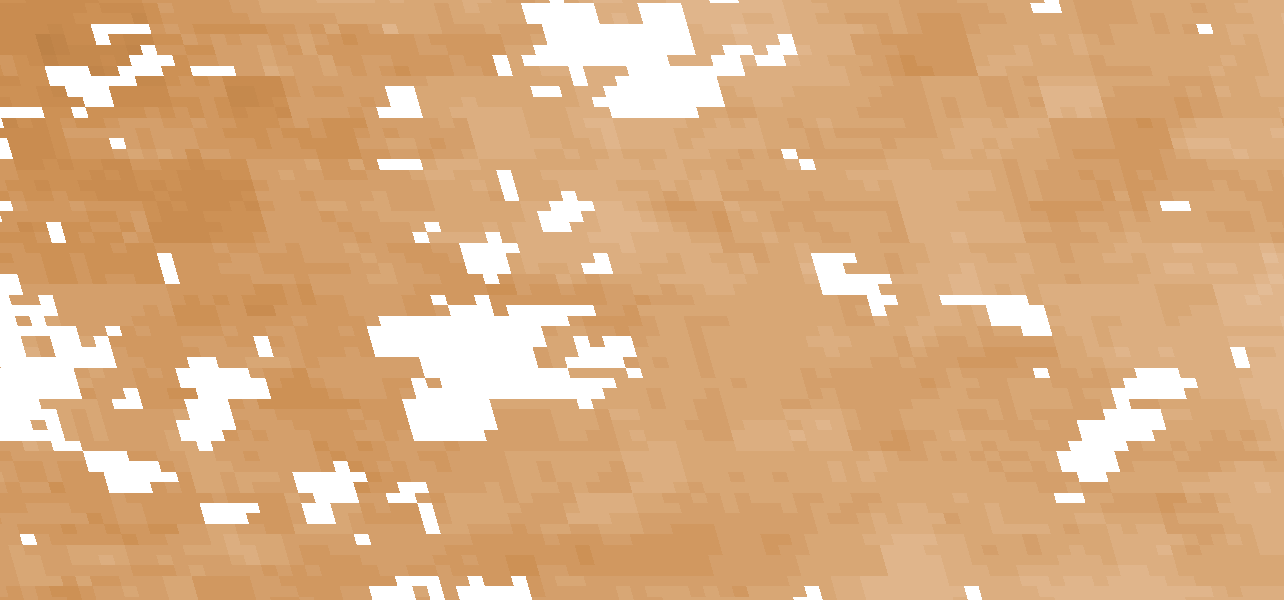
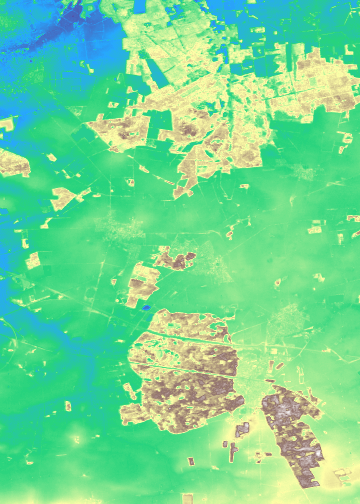

In [ ]:
# Build the final map. A fresh Map is constructed here each run, so re-running
# THIS cell is safe (folium has no remove-layer API; don't re-run layer-adding
# code against an existing map or layers stack up as duplicates).

m = folium.Map(location=[LAT, LON], zoom_start=13, tiles=None)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap", show=True).add_to(m)
folium.TileLayer("Esri.WorldImagery", name="Satellite (Esri)", show=False).add_to(m)

folium.Marker([LAT, LON], tooltip="test point",
              popup=f"Lehrte field {LAT}, {LON}").add_to(m)

for lyr in (*soilgrids_layers(), fetch_soilgrids_aoi(),
            *nibis_layers(), bgr_layer()):
    lyr.add_to(m)
dem = fetch_dem_overlay()
if dem is not None:
    dem.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
folium.LatLngPopup().add_to(m)  # click anywhere to read coordinates

html = OUT / "soil_raster_map.html"
m.save(str(html))
print(f"\nSaved {html.resolve()}")
print("VS Code blocks inline folium iframes -> open the HTML file in a browser.")
m

In [ ]:
# Companion: point identification via WMS GetFeatureInfo.
# Rasters are for display; to READ values at a spot, click the map (LatLngPopup)
# to grab coordinates, then call nibis_identify(lat, lon, layer).
# EPSG:3857 is used because its axis order is plain x,y (EPSG:4326 in WMS 1.3.0
# is lat,lon; EPSG:25832 is northing,easting -- both classic footguns).

import math

KEEP_ATTRS = ("BOTYP", "BOTYP_KLARTEXT", "NUTZUNG", "WPFL", "BFR", "GWS",
              "BODENZ", "ACKERZ", "KLASSENZEICHEN")

def _to_mercator(lat, lon):
    x = 6378137 * math.radians(lon)
    y = 6378137 * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2))
    return x, y

def nibis_identify(lat, lon, layer="L816", buffer_m=500):
    """GetFeatureInfo at a point. The pixel I/J addresses the BBOX centre,
    so the buffer (not the pixel size) controls the search window."""
    x, y = _to_mercator(lat, lon)
    params = dict(
        SERVICE="WMS", VERSION="1.3.0", REQUEST="GetFeatureInfo",
        LAYERS=layer, QUERY_LAYERS=layer, STYLES="", CRS="EPSG:3857",
        BBOX=f"{x - buffer_m},{y - buffer_m},{x + buffer_m},{y + buffer_m}",
        WIDTH=101, HEIGHT=101, I=50, J=50,
        INFO_FORMAT="text/plain", FEATURE_COUNT=5,
    )
    txt = requests.get(NIBIS_WMS, params=params, timeout=TIMEOUT).text.strip()
    if not txt or "Keine Treffer" in txt:
        return f"{layer}: no feature (widen buffer_m or click farmland, not a town)"
    useful = [ln for ln in txt.splitlines() if any(k in ln for k in KEEP_ATTRS)]
    return "\n".join(useful) if useful else txt

print("--- L816 BK50 soil type ---")
print(nibis_identify(LAT, LON, "L816"))
print("\n--- L849 Bodenzahl (small parcels: 1000 m buffer) ---")
print(nibis_identify(LAT, LON, "L849", buffer_m=1000))

--- L816 BK50 soil type ---
BOTYP	:G4
BOTYP_KLARTEXT	:Tiefer Gley
NUTZUNG	:A

--- L849 Bodenzahl (small parcels: 1000 m buffer) ---
KLASSENZEICHEN	:L/S-Al
KLASSENZEICHEN_KLARTEXT	:Lehm über Sand/-/Schwemmlandböden
KLASSENZEICHEN_SEP	:L/S;-;Al
BODENZ	:56
ACKERZ	:55


## Gotchas learned (all verified 2026-10-02)

- **SoilGrids WMS requires an explicit empty `STYLES=`** parameter — without it you get HTTP 200 with a `ServiceExceptionReport` XML body (`MissingParameterValue`), not an image. Always check Content-Type, not just status.
- **NIBIS**: bake `?PKGID=24` into the WmsTileLayer base URL (Leaflet appends its own params with `&`). BK50 renders only below ~1:167k → tiles above zoom ~12 are transparent, not an error. `L272` (Klassenzeichen) was removed from the service; those attributes now live on `L849`.
- **NIBIS GetFeatureInfo**: "Keine Treffer für diese Ebene" is HTTP 200 with no data — treat as a miss. Pixel `I`/`J` addresses the BBOX *centre*, so widen the BBOX (buffer), not the pixel.
- **BGR BÜK200 WMS** has one layer per map sheet; comma-joining all 57 layer names in `LAYERS` renders the whole country in one request (~230 KB for a 512² Germany-wide image).
- **WMS 1.3.0 axis order**: `EPSG:4326` BBOX is `minLat,minLon,maxLat,maxLon`; `EPSG:25832` is northing,easting. `EPSG:3857` is safe x,y — used for GetFeatureInfo here.
- **GLO-30 tiles are 1°×1°** — the test point is 800 m east of the E009/E010 tile boundary, so a windowed single-tile read must start east of lon 10.0. Cross-tile AOIs need a merge (rasterio.merge) or per-tile reads.
- **Open-Meteo has no raster product** (point time series) — it's the time-dimension companion, not a map layer.
- **folium in VS Code**: the inline iframe is blocked ("Make this Notebook Trusted…") even in trusted workspaces — use the saved HTML. folium `Map` has no remove API; rebuild the map object instead of re-adding layers. Both work fine in Colab.